In [1]:
from pathlib import Path
import sys
import json

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

public_root = Path(config["public_root"])

print("Public root exists:", public_root.exists())
print(public_root)

Public root exists: True
C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI


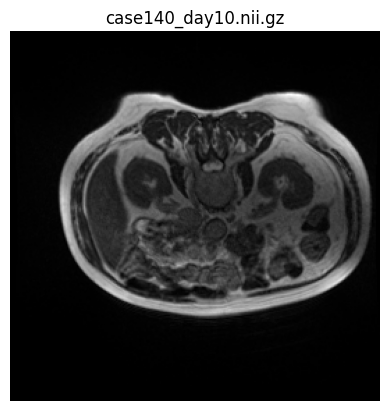

In [2]:
from src.eda.build_public_scan_inventory import find_nifti_files
import nibabel as nib
import matplotlib.pyplot as plt
import json
from pathlib import Path

config_path = project_root / "configs" / "datasets" / "public_dataset.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

public_root = Path(config["public_root"])
files = find_nifti_files(public_root)

scan_path = files[90]
data = nib.load(str(scan_path)).get_fdata()

slice_idx = data.shape[2] // 2
plt.imshow(data[:, :, slice_idx].T, cmap="gray", origin="lower")
plt.title(scan_path.name)
plt.axis("off")
plt.show()

In [4]:
from pathlib import Path
import json
import sys

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

public_root = Path(config["public_root"])

scan_path = public_root / "case9_day22.nii.gz"

print("Project root:", project_root)
print("Public root:", public_root)
print("Scan path exists:", scan_path.exists())
print("Scan path:", scan_path)

Project root: C:\Users\P102832\Downloads\thesis_segmentation
Public root: C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI
Scan path exists: True
Scan path: C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI\case9_day22.nii.gz


scan shape: (360, 310, 144)


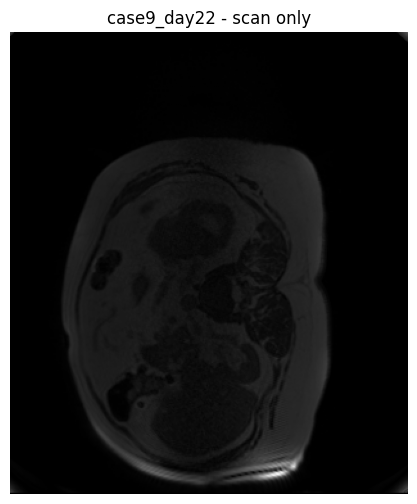

In [5]:
from src.eda.visualize_masks import load_nifti, show_nifti_slice_only

scan_volume, scan_img = load_nifti(scan_path)

print("scan shape:", scan_volume.shape)

slice_idx = scan_volume.shape[2] // 2

show_nifti_slice_only(
    scan_volume,
    slice_idx=slice_idx,
    axis=2,
    title="case9_day22 - scan only"
)

scan exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\raw\public_same_format\NIFTI\case9_day22.nii.gz
mask exists: True C:\Users\P102832\Downloads\thesis_segmentation\data\interim\public_same_format\totalsegmentator_ml\case9_day22.nii.gz
scan shape: (360, 310, 144)
mask shape: (360, 310, 144)


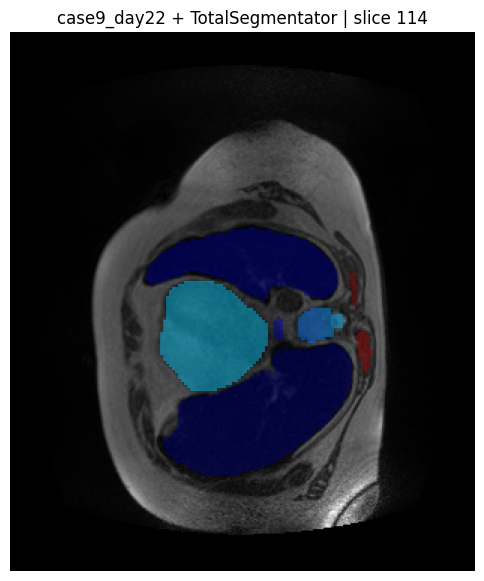

In [7]:
from pathlib import Path
import json
import sys
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

config_path = project_root / "configs" / "datasets" / "public_dataset.json"

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

scan_path = Path(config["public_root"]) / "case9_day22.nii.gz"
mask_path = Path(config["totalseg_root"]) / "case9_day22.nii.gz"

print("scan exists:", scan_path.exists(), scan_path)
print("mask exists:", mask_path.exists(), mask_path)

scan_img = nib.load(str(scan_path))
mask_img = nib.load(str(mask_path))

scan = scan_img.get_fdata()
mask = mask_img.get_fdata()

print("scan shape:", scan.shape)
print("mask shape:", mask.shape)

assert scan.shape == mask.shape, f"Shape mismatch: {scan.shape} vs {mask.shape}"

# choose a slice with the most mask pixels
mask_binary = mask > 0
scores = mask_binary.sum(axis=(0, 1))
slice_idx = int(np.argmax(scores))

scan_slice = scan[:, :, slice_idx]
mask_slice = mask[:, :, slice_idx]

# normalize scan only for display
scan_min = scan_slice.min()
scan_max = scan_slice.max()
if scan_max > scan_min:
    scan_slice = (scan_slice - scan_min) / (scan_max - scan_min)
else:
    scan_slice = np.zeros_like(scan_slice)

mask_overlay = np.ma.masked_where(mask_slice <= 0, mask_slice)

plt.figure(figsize=(7, 7))
plt.imshow(scan_slice, cmap="gray", origin="lower")
plt.imshow(mask_overlay, cmap="jet", alpha=0.45, origin="lower")
plt.title(f"case9_day22 + TotalSegmentator | slice {slice_idx}")
plt.axis("off")
plt.show()

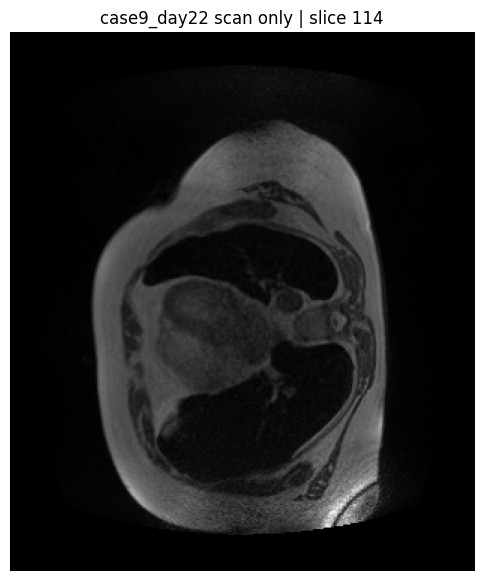

In [8]:
plt.figure(figsize=(7, 7))
plt.imshow(scan[:, :, slice_idx], cmap="gray", origin="lower")
plt.title(f"case9_day22 scan only | slice {slice_idx}")
plt.axis("off")
plt.show()